# **MNIST에 랜덤 포레스트 모델 적용하기**

### 라이브러리

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier as RFC
from lightgbm import LGBMClassifier as LGBMC
from sklearn.metrics import confusion_matrix, accuracy_score
import warnings; warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 44.1 MB/s eta 0:00:00


### MNIST 데이터셋 불러오기

In [ ]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("훈련 데이터의 입력 형태: ", x_train.shape)
print("검증 데이터의 입력 형태: ", x_test.shape)

print("훈련 데이터의 타깃 형태: ", y_train.shape)
print("검증 데이터의 타깃 형태: ", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
훈련 데이터의 입력 형태:  (60000, 28, 28)
검증 데이터의 입력 형태:  (10000, 28, 28)
훈련 데이터의 타깃 형태:  (60000,)
검증 데이터의 타깃 형태:  (10000,)


### 입력 데이터 변환하기

In [ ]:
x_train = x_train.reshape(-1, 28*28)  # (60000, 28, 28) -> (60000, 784)
x_test = x_test.reshape(-1, 28*28)    # (10000, 28, 28) -> (10000, 784)

print("변환된 입력 데이터 형태")
print(" -훈련 데이터: ", x_train.shape)
print(" -검증 데이터: ", x_test.shape)

변환된 입력 데이터 형태
 -훈련 데이터:  (60000, 784)
 -검증 데이터:  (10000, 784)


### 랜덤포레스트 모델 설정과 학습

In [ ]:
model=RFC(n_estimators=50, random_state=42)  # 하이퍼 파라미터 튜닝 필요
model.fit(x_train, y_train)

# 예측 및 평가
y_pred = model.predict(x_test)
y_pred

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

### 예측 정확도 평가

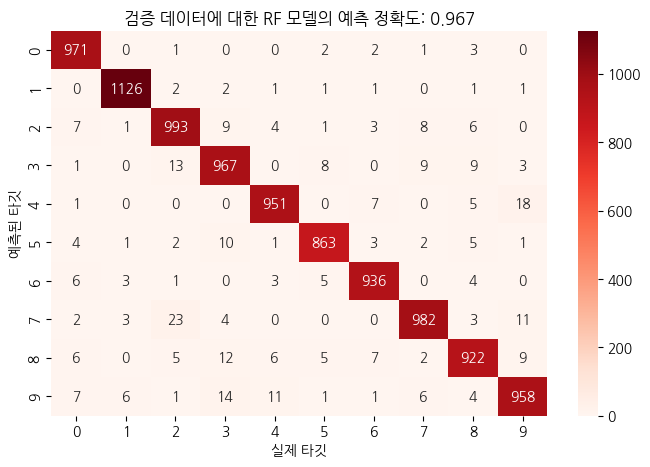

In [ ]:
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title(f"검증 데이터에 대한 RF 모델의 예측 정확도: {accuracy:.3}")
plt.xlabel("실제 타깃")
plt.ylabel("예측된 타깃")
plt.show()

### **트리 수의 최적화 원리**
* **오컴의 면도날 (Occam's razor)**: 예측 능력이 비슷하면 가장 단순한 모델이 더 선호된다.
* n_estimators를 점점 늘려서 정확도가 거의 증가하지 않는 지점에서 멈춤

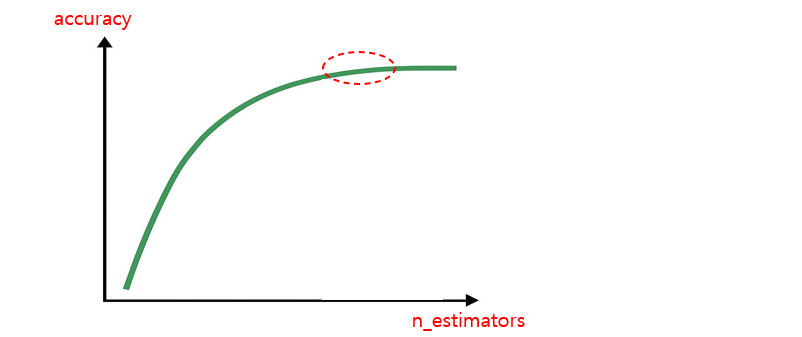